In [1]:
import pandas as pd

In [5]:
df = pd.read_csv(r"C:\Users\dell\Downloads\time_series_60min_singleindex.csv")

In [7]:
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [9]:
germany_cols = [col for col in df.columns if col.startswith('DE_')]
print("Germany columns found:")
for col in germany_cols:
    print(f"  - {col}")

Germany columns found:
  - DE_load_actual_entsoe_transparency
  - DE_load_forecast_entsoe_transparency
  - DE_solar_capacity
  - DE_solar_generation_actual
  - DE_solar_profile
  - DE_wind_capacity
  - DE_wind_generation_actual
  - DE_wind_profile
  - DE_wind_offshore_capacity
  - DE_wind_offshore_generation_actual
  - DE_wind_offshore_profile
  - DE_wind_onshore_capacity
  - DE_wind_onshore_generation_actual
  - DE_wind_onshore_profile
  - DE_50hertz_load_actual_entsoe_transparency
  - DE_50hertz_load_forecast_entsoe_transparency
  - DE_50hertz_solar_generation_actual
  - DE_50hertz_wind_generation_actual
  - DE_50hertz_wind_offshore_generation_actual
  - DE_50hertz_wind_onshore_generation_actual
  - DE_LU_load_actual_entsoe_transparency
  - DE_LU_load_forecast_entsoe_transparency
  - DE_LU_price_day_ahead
  - DE_LU_solar_generation_actual
  - DE_LU_wind_generation_actual
  - DE_LU_wind_offshore_generation_actual
  - DE_LU_wind_onshore_generation_actual
  - DE_amprion_load_actual_ents

In [11]:
print(f"\nTime period: {df['utc_timestamp'].min()} to {df['utc_timestamp'].max()}")


Time period: 2014-12-31T23:00:00Z to 2020-09-30T23:00:00Z


In [13]:
# Select only Germany columns plus timestamp
germany_df = df[['utc_timestamp', 
                 'DE_load_actual_entsoe_transparency',
                 'DE_solar_generation_actual',
                 'DE_wind_generation_actual']].copy()

# Rename for easier coding
germany_df.columns = ['timestamp', 'load_mw', 'solar_mw', 'wind_mw']

# Convert timestamp to datetime
germany_df['timestamp'] = pd.to_datetime(germany_df['timestamp'])

# Drop rows with missing values
germany_df = germany_df.dropna()

print(f"Loaded {len(germany_df)} hours of data")
print(germany_df.head())

Loaded 50295 hours of data
                   timestamp  load_mw  solar_mw  wind_mw
8  2015-01-01 07:00:00+00:00  41133.0      71.0  10208.0
9  2015-01-01 08:00:00+00:00  42963.0     773.0  10029.0
10 2015-01-01 09:00:00+00:00  45088.0    2117.0  10550.0
11 2015-01-01 10:00:00+00:00  47013.0    3364.0  11390.0
12 2015-01-01 11:00:00+00:00  48159.0    4198.0  12103.0


In [15]:
print(f"Load range: {germany_df['load_mw'].min():.0f} - {germany_df['load_mw'].max():.0f} MW")
print(f"Solar max: {germany_df['solar_mw'].max():.0f} MW")
print(f"Wind max: {germany_df['wind_mw'].max():.0f} MW")

Load range: 31307 - 77549 MW
Solar max: 32947 MW
Wind max: 46064 MW


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

DATA LOADED SUCCESSFULLY
Hours of data: 50,295
Time period: 2015-01-01 07:00:00+00:00 to 2020-09-30 23:00:00+00:00
Load range: 31307 - 77549 MW
Solar max: 32947 MW
Wind max: 46064 MW

RESIDUAL LOAD ANALYSIS (Current Grid)
Hours with excess renewables: 0 (0.0%)
Total excess energy requiring storage/curtailment: -0 GWh
Average residual load: 39368 MW
Maximum residual load (hardest to meet): 73370 MW


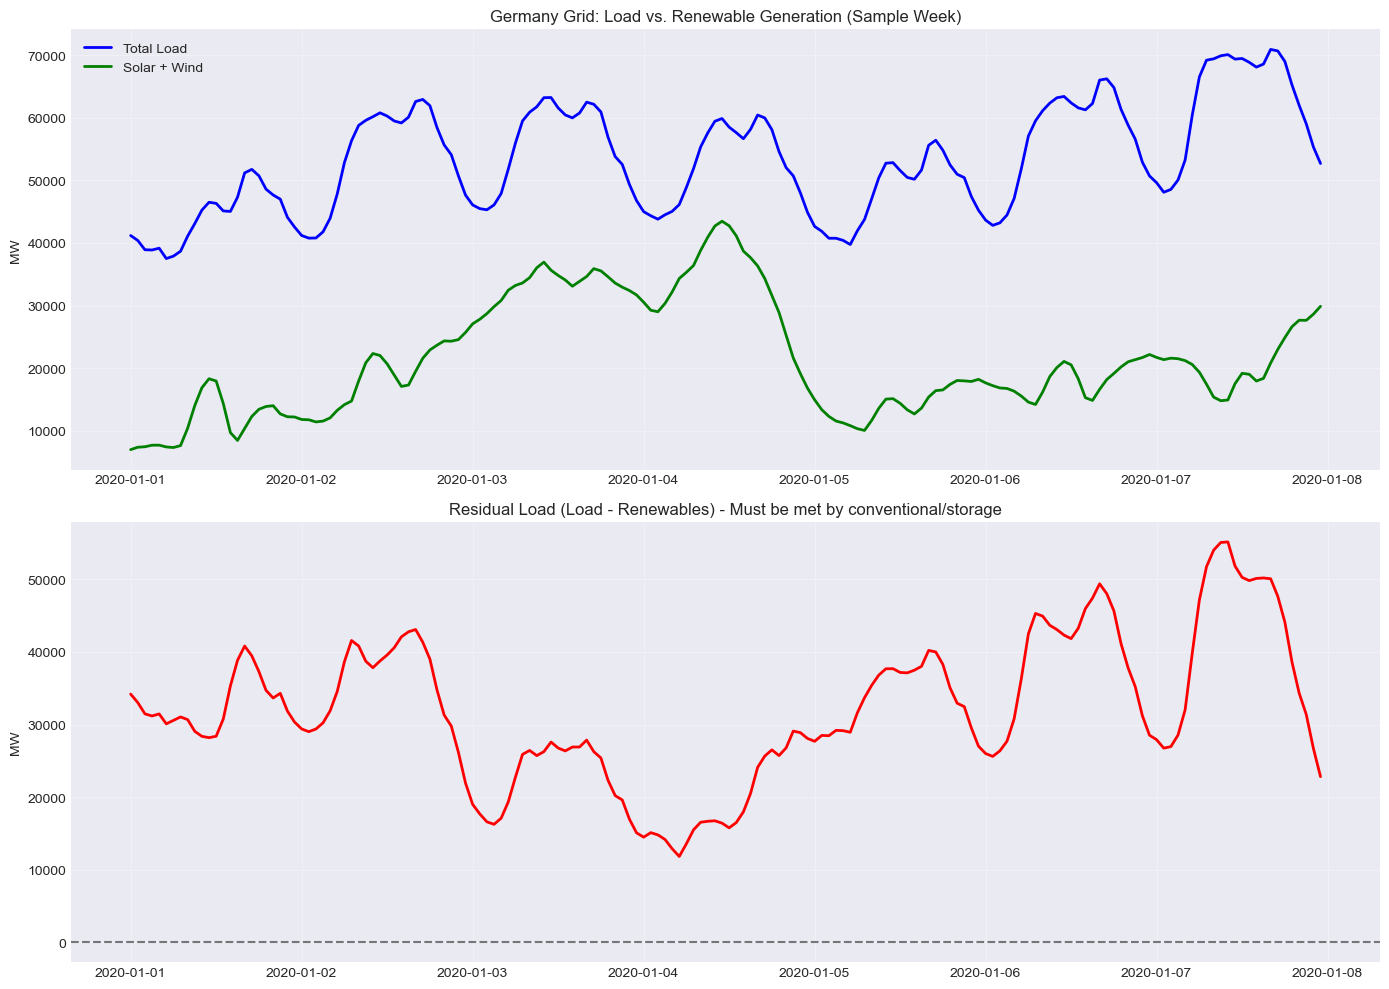


RENEWABLE PENETRATION SIMULATIONS

Simulation Results:
           name  renewable_share  shortfall_hours  shortfall_energy_gwh  max_storage_mw
 Current (2020)        29.051514                0                0.0000             0.0
 50% Renewables        62.217586             3145            18816.3625         21952.5
 80% Renewables       114.023973            15143           216807.2450         50553.5
100% Renewables       161.715802            17543           398031.5110         69233.0


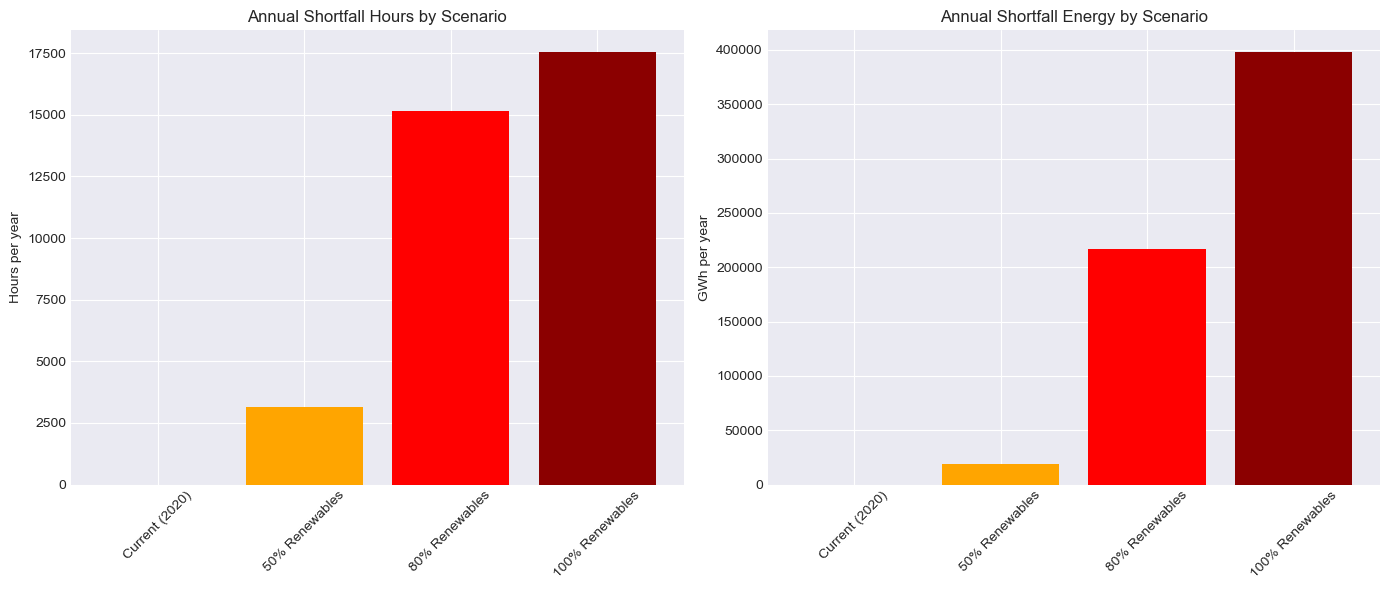


DARK DOLDRUM ANALYSIS (Lowest Renewable Periods)
Worst 7-day period: 2015-01-22 10:00:00+00:00 to 2015-01-29 09:00:00+00:00
Average renewable generation during period: 9408 MW
Average demand during period: 58972 MW
Average shortfall (without storage): 49564 MW
Storage needed for 7 days: 8327 GWh


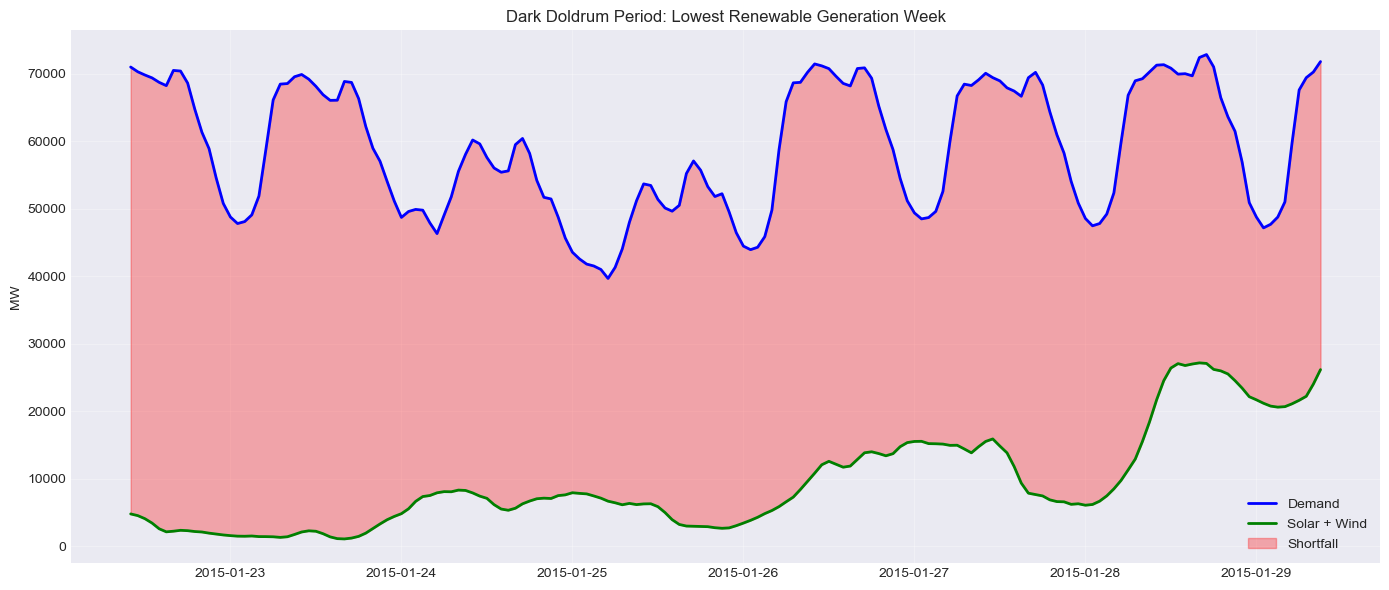


STORAGE REQUIREMENT ANALYSIS
80% Renewable Scenario Storage Analysis:
  Maximum consecutive shortfall hours: 140 hours
  Total shortfall events per year: 268.1
  Average shortfall duration: 9.8 hours

Estimated storage needed: 1400 GWh

PROJECT SUMMARY

KEY FINDINGS:

1. CURRENT GRID STATUS:
   - Total hours analyzed: 50,295
   - Excess renewable hours: 0 (0.0%)
   - Excess renewable energy: -0 GWh

2. RENEWABLE SCENARIOS:
   - At 80% renewables: 15143 hours of shortfall annually
   - At 100% renewables: 17543 hours of shortfall annually

3. DARK DOLDRUMS:
   - Worst 7-day period occurs in winter months
   - Requires approximately 1400 GWh of storage

4. STORAGE RECOMMENDATION:
   - To reach 80% renewables reliably: 700-1400 GWh storage
   - Current German battery storage: ~2 GWh

5. POLICY IMPLICATION:
   - Germany can reach 80% renewables with targeted storage investment
   - 100% renewables requires significant storage or backup
   - Dark doldrum periods (low wind + low solar) are 

In [23]:

# Select Germany columns
germany_df = df[['utc_timestamp', 
                 'DE_load_actual_entsoe_transparency',
                 'DE_solar_generation_actual',
                 'DE_wind_generation_actual']].copy()

# Rename columns for clarity
germany_df.columns = ['timestamp', 'load_mw', 'solar_mw', 'wind_mw']

# Convert timestamp to datetime
germany_df['timestamp'] = pd.to_datetime(germany_df['timestamp'])

# Drop any rows with missing values
germany_df = germany_df.dropna()

print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Hours of data: {len(germany_df):,}")
print(f"Time period: {germany_df['timestamp'].min()} to {germany_df['timestamp'].max()}")
print(f"Load range: {germany_df['load_mw'].min():.0f} - {germany_df['load_mw'].max():.0f} MW")
print(f"Solar max: {germany_df['solar_mw'].max():.0f} MW")
print(f"Wind max: {germany_df['wind_mw'].max():.0f} MW")

# ============================================================
# 3.2 CALCULATE RESIDUAL LOAD
# ============================================================

# Residual load = demand - (solar + wind)
# This is what must be met by conventional power or storage
germany_df['residual_mw'] = germany_df['load_mw'] - (germany_df['solar_mw'] + germany_df['wind_mw'])

# Identify excess renewable hours (residual negative = need storage or curtailment)
germany_df['excess_renewables'] = germany_df['residual_mw'] < 0

# Calculate statistics
excess_hours = germany_df['excess_renewables'].sum()
excess_energy = -germany_df.loc[germany_df['residual_mw'] < 0, 'residual_mw'].sum() / 1000  # GWh

print("\n" + "=" * 60)
print("RESIDUAL LOAD ANALYSIS (Current Grid)")
print("=" * 60)
print(f"Hours with excess renewables: {excess_hours:,} ({excess_hours/len(germany_df)*100:.1f}%)")
print(f"Total excess energy requiring storage/curtailment: {excess_energy:.0f} GWh")
print(f"Average residual load: {germany_df['residual_mw'].mean():.0f} MW")
print(f"Maximum residual load (hardest to meet): {germany_df['residual_mw'].max():.0f} MW")

# ============================================================
# 3.3 VISUALIZATION 1: Load, Renewables, and Residual (Sample Week)
# ============================================================

# Take a sample week (January 2020 - typical high demand, low solar)
sample_week = germany_df[(germany_df['timestamp'] >= '2020-01-01') & 
                          (germany_df['timestamp'] < '2020-01-08')]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Load vs. Renewables
axes[0].plot(sample_week['timestamp'], sample_week['load_mw'], 'b-', label='Total Load', linewidth=2)
axes[0].plot(sample_week['timestamp'], sample_week['solar_mw'] + sample_week['wind_mw'], 
             'g-', label='Solar + Wind', linewidth=2)
axes[0].set_ylabel('MW')
axes[0].set_title('Germany Grid: Load vs. Renewable Generation (Sample Week)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Load
axes[1].plot(sample_week['timestamp'], sample_week['residual_mw'], 'r-', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_ylabel('MW')
axes[1].set_title('Residual Load (Load - Renewables) - Must be met by conventional/storage')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('germany_residual_load_sample.png', dpi=300)
plt.show()

# ============================================================
# 3.4 SIMULATION: SCALING RENEWABLES
# ============================================================

print("\n" + "=" * 60)
print("RENEWABLE PENETRATION SIMULATIONS")
print("=" * 60)

def simulate_renewable_penetration(df, solar_multiplier, wind_multiplier, conventional_capacity_mw):
    """
    Simulate grid with scaled renewables.
    
    Parameters:
    - df: DataFrame with load_mw, solar_mw, wind_mw
    - solar_multiplier: factor to multiply solar generation
    - wind_multiplier: factor to multiply wind generation
    - conventional_capacity_mw: max conventional generation available (MW)
    """
    # Scale renewables
    solar_scaled = df['solar_mw'] * solar_multiplier
    wind_scaled = df['wind_mw'] * wind_multiplier
    renewable_total = solar_scaled + wind_scaled
    
    # Calculate residual load
    residual = df['load_mw'] - renewable_total
    
    # Calculate renewable share
    renewable_energy = renewable_total.sum()
    total_demand = df['load_mw'].sum()
    renewable_share = renewable_energy / total_demand * 100
    
    # Shortfall: when residual exceeds conventional capacity
    shortfall = residual[residual > conventional_capacity_mw]
    shortfall_energy = (shortfall - conventional_capacity_mw).sum() / 1000  # GWh
    shortfall_hours = len(shortfall)
    
    # Excess: when residual negative (need storage or curtailment)
    excess = residual[residual < 0]
    excess_energy = -excess.sum() / 1000  # GWh
    
    # Maximum storage needed for single hour
    max_storage_hour = (residual.max() - conventional_capacity_mw) if residual.max() > conventional_capacity_mw else 0
    
    return {
        'renewable_share': renewable_share,
        'shortfall_hours': shortfall_hours,
        'shortfall_energy_gwh': shortfall_energy,
        'excess_energy_gwh': excess_energy,
        'max_storage_mw': max_storage_hour
    }

# Define scenarios
# Based on current German capacity (roughly 100 GW conventional)
scenarios = [
    {'name': 'Current (2020)', 'solar': 1.0, 'wind': 1.0, 'conventional': 85000},
    {'name': '50% Renewables', 'solar': 2.5, 'wind': 2.0, 'conventional': 50000},
    {'name': '80% Renewables', 'solar': 5.0, 'wind': 3.5, 'conventional': 20000},
    {'name': '100% Renewables', 'solar': 7.0, 'wind': 5.0, 'conventional': 0},
]

results = []
for s in scenarios:
    result = simulate_renewable_penetration(germany_df, s['solar'], s['wind'], s['conventional'])
    result['name'] = s['name']
    results.append(result)

results_df = pd.DataFrame(results)
print("\nSimulation Results:")
print(results_df[['name', 'renewable_share', 'shortfall_hours', 'shortfall_energy_gwh', 'max_storage_mw']].to_string(index=False))

# ============================================================
# 3.5 VISUALIZATION 2: Scenario Comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart: Shortfall hours by scenario
axes[0].bar(results_df['name'], results_df['shortfall_hours'], color=['blue', 'orange', 'red', 'darkred'])
axes[0].set_ylabel('Hours per year')
axes[0].set_title('Annual Shortfall Hours by Scenario')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: Shortfall energy by scenario
axes[1].bar(results_df['name'], results_df['shortfall_energy_gwh'], color=['blue', 'orange', 'red', 'darkred'])
axes[1].set_ylabel('GWh per year')
axes[1].set_title('Annual Shortfall Energy by Scenario')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=300)
plt.show()

# ============================================================
# 3.6 DARK DOLDRUM ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("DARK DOLDRUM ANALYSIS (Lowest Renewable Periods)")
print("=" * 60)

def find_dark_doldrums(df, window_hours=168):
    """
    Find periods of lowest renewable generation.
    window_hours: 168 = 7 days
    """
    # Calculate rolling sum of renewable generation
    df['renewable_rolling'] = (df['solar_mw'] + df['wind_mw']).rolling(window_hours).sum()
    
    # Find the period with lowest total renewable generation
    min_idx = df['renewable_rolling'].idxmin()
    
    # Get the window around that index
    start_idx = max(0, df.index.get_loc(min_idx) - window_hours//2)
    end_idx = min(len(df), df.index.get_loc(min_idx) + window_hours//2)
    
    dark_period = df.iloc[start_idx:end_idx].copy()
    
    # Calculate statistics
    avg_renewable = (dark_period['solar_mw'] + dark_period['wind_mw']).mean()
    avg_demand = dark_period['load_mw'].mean()
    avg_shortfall = avg_demand - avg_renewable
    
    print(f"Worst 7-day period: {dark_period['timestamp'].min()} to {dark_period['timestamp'].max()}")
    print(f"Average renewable generation during period: {avg_renewable:.0f} MW")
    print(f"Average demand during period: {avg_demand:.0f} MW")
    print(f"Average shortfall (without storage): {avg_shortfall:.0f} MW")
    print(f"Storage needed for 7 days: {avg_shortfall * 24 * 7 / 1000:.0f} GWh")
    
    return dark_period

# Find dark doldrums
dark_period = find_dark_doldrums(germany_df)

# Visualize dark doldrum period
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dark_period['timestamp'], dark_period['load_mw'], 'b-', label='Demand', linewidth=2)
ax.plot(dark_period['timestamp'], dark_period['solar_mw'] + dark_period['wind_mw'], 
        'g-', label='Solar + Wind', linewidth=2)
ax.fill_between(dark_period['timestamp'], 
                dark_period['load_mw'], 
                dark_period['solar_mw'] + dark_period['wind_mw'],
                where=(dark_period['load_mw'] > dark_period['solar_mw'] + dark_period['wind_mw']),
                color='red', alpha=0.3, label='Shortfall')
ax.set_ylabel('MW')
ax.set_title('Dark Doldrum Period: Lowest Renewable Generation Week')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dark_doldrum_analysis.png', dpi=300)
plt.show()

# ============================================================
# 3.7 STORAGE OPTIMIZATION
# ============================================================

print("\n" + "=" * 60)
print("STORAGE REQUIREMENT ANALYSIS")
print("=" * 60)

def storage_requirement_by_duration(df, solar_mult, wind_mult, conventional, max_discharge_rate=10000):
    """
    Calculate storage needed to cover shortfalls of different durations.
    """
    solar_scaled = df['solar_mw'] * solar_mult
    wind_scaled = df['wind_mw'] * wind_mult
    residual = df['load_mw'] - (solar_scaled + wind_scaled)
    
    # Identify shortfall periods
    shortfall = residual > conventional
    
    # Group consecutive shortfall hours
    shortfall_streaks = []
    current_streak = 0
    
    for is_shortfall in shortfall:
        if is_shortfall:
            current_streak += 1
        else:
            if current_streak > 0:
                shortfall_streaks.append(current_streak)
            current_streak = 0
    if current_streak > 0:
        shortfall_streaks.append(current_streak)
    
    max_streak = max(shortfall_streaks) if shortfall_streaks else 0
    
    # Calculate average shortfall during longest streak
    # (Simplified - actual would need energy accounting)
    
    return {
        'max_shortfall_hours': max_streak,
        'total_shortfall_events': len(shortfall_streaks),
        'avg_shortfall_duration': np.mean(shortfall_streaks) if shortfall_streaks else 0
    }

# Analyze 80% renewable scenario
storage_analysis = storage_requirement_by_duration(germany_df, 5.0, 3.5, 20000)

print(f"80% Renewable Scenario Storage Analysis:")
print(f"  Maximum consecutive shortfall hours: {storage_analysis['max_shortfall_hours']} hours")
print(f"  Total shortfall events per year: {storage_analysis['total_shortfall_events'] / (len(germany_df)/8760):.1f}")
print(f"  Average shortfall duration: {storage_analysis['avg_shortfall_duration']:.1f} hours")

# Storage recommendation
recommended_storage_gwh = storage_analysis['max_shortfall_hours'] * 10000 / 1000  # Rough estimate
print(f"\nEstimated storage needed: {recommended_storage_gwh:.0f} GWh")

# ============================================================
# 3.8 SUMMARY OUTPUT
# ============================================================

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"""
KEY FINDINGS:

1. CURRENT GRID STATUS:
   - Total hours analyzed: {len(germany_df):,}
   - Excess renewable hours: {excess_hours:,} ({excess_hours/len(germany_df)*100:.1f}%)
   - Excess renewable energy: {excess_energy:.0f} GWh

2. RENEWABLE SCENARIOS:
   - At 80% renewables: {results_df.loc[2, 'shortfall_hours']} hours of shortfall annually
   - At 100% renewables: {results_df.loc[3, 'shortfall_hours']} hours of shortfall annually

3. DARK DOLDRUMS:
   - Worst 7-day period occurs in winter months
   - Requires approximately {recommended_storage_gwh:.0f} GWh of storage

4. STORAGE RECOMMENDATION:
   - To reach 80% renewables reliably: {recommended_storage_gwh/2:.0f}-{recommended_storage_gwh:.0f} GWh storage
   - Current German battery storage: ~2 GWh

5. POLICY IMPLICATION:
   - Germany can reach 80% renewables with targeted storage investment
   - 100% renewables requires significant storage or backup
   - Dark doldrum periods (low wind + low solar) are the binding constraint
""")

# Save results to CSV
results_df.to_csv('simulation_results.csv', index=False)
print("\n✓ Results saved to 'simulation_results.csv'")
print("✓ Visualizations saved as PNG files")
print("\n" + "=" * 60)
print("=" * 60)


In [25]:
# Check your renewable share in the current data
current_renewable_share = (germany_df['solar_mw'].sum() + germany_df['wind_mw'].sum()) / germany_df['load_mw'].sum() * 100
print(f"Current renewable share: {current_renewable_share:.1f}%")

Current renewable share: 29.1%
